In [1]:
import numpy as np
import os
import pandas as pd

path = os.path.join('Data', 'test.csv')
data = pd.read_csv(path)

x, y_name = data.drop('Air_Quality', axis=1), data['Air_Quality']
y_dum = pd.get_dummies(y_name)
y = np.argmax(y_dum[y_dum.columns].values, axis=1)

x

,Temperature,Humidity,PM10,NO2,SO2,CO
0,0.276596,-0.628249,0.313364,-0.203390,-0.032258,0.075949
1,-0.946809,-0.171751,-0.685714,-0.703390,-0.634409,-0.481013
2,0.063830,-0.302825,-0.228571,-0.279661,-0.505376,-0.303797
3,0.606383,0.099435,0.420276,0.728814,0.505376,1.139241
4,0.393617,0.230508,0.011060,-0.618644,0.376344,0.215190
...,...,...,...,...,...,...
995,1.287234,0.555932,1.128111,0.881356,0.688172,1.341772
996,0.712766,0.149153,-0.523502,0.135593,0.645161,0.468354
997,0.904255,-0.501695,0.022120,-0.279661,0.075269,0.202532
998,-0.893617,-0.284746,0.051613,0.398305,-0.021505,0.177215


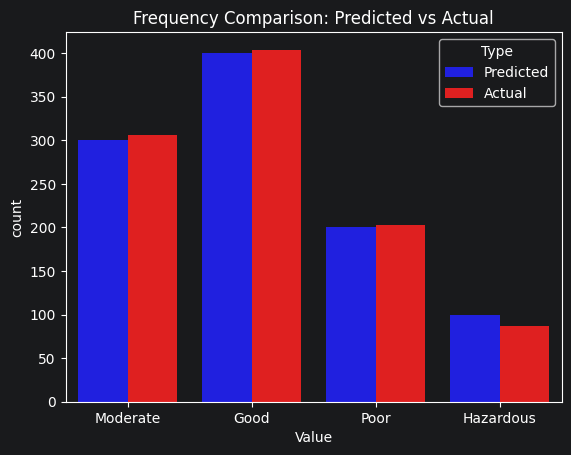

In [2]:
from utils.Predictor import Predictor
import matplotlib.pyplot as plt
import seaborn as sns

model_path = os.path.join('Models', 'Top_2')
predictor_obj = Predictor(model_path)

pred = predictor_obj.human_pred(x)

ax = plt.subplot()
df_plot = pd.DataFrame({
    'Value': np.concatenate([y_name, pred]),
    'Type': ['Predicted'] * len(pred) + ['Actual'] * len(y_name)
})
sns.countplot(data=df_plot, x='Value', hue='Type', ax=ax, palette={'Predicted': 'blue', 'Actual': 'red'})
ax.set_title('Frequency Comparison: Predicted vs Actual')
plt.show()

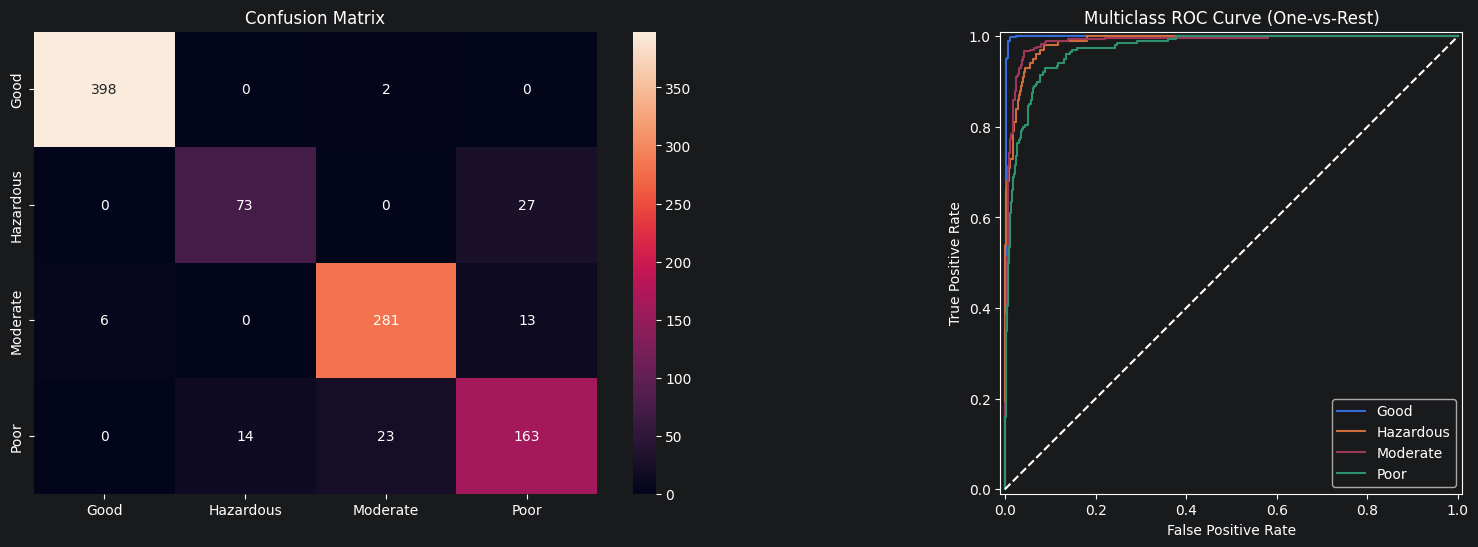

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       0.84      0.73      0.78       100
           2       0.92      0.94      0.93       300
           3       0.80      0.81      0.81       200

    accuracy                           0.92      1000
   macro avg       0.89      0.87      0.88      1000
weighted avg       0.91      0.92      0.91      1000



In [3]:
predictor_obj.metric_report(x, y)